In [4]:
# For Data Manipulation
import numpy as np
import pandas as pd 

# For Data Visulization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# For Stats
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest , proportion_confint

In [5]:
df = pd.read_csv(r"C:\Users\iaman\ML\INTERNSHIP TASK\Datasets\bank-additional-full.csv", sep=";")

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 41188 rows, 21 columns


In [6]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
31844,59,retired,divorced,high.school,unknown,no,no,cellular,may,thu,...,2,999,1,failure,-1.8,92.893,-46.2,1.327,5099.1,no
6995,48,admin.,divorced,high.school,no,no,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no
21474,33,technician,single,professional.course,no,no,yes,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,no
29195,35,admin.,married,university.degree,no,no,no,cellular,apr,fri,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,no
17160,45,admin.,married,professional.course,no,no,no,cellular,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no


In [7]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [8]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [9]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [10]:
for col in ['job', 'marital', 'education', 'contact', 'poutcome', 'y']:
    print(f"\n{col}:\n{df[col].value_counts()}")


job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

contact:
contact
cellular     26144
telephone    15044
Name: count, dtype: int64

poutcome:
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

y:
y
no     36548
yes     4640
Name: count, dtype: int64


In [11]:
print("\n'Unknown' counts:")
for col in df.select_dtypes(include='object').columns:
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        print(f"  {col}: {unk} unknowns ({unk/len(df)*100:.1f}%)")


'Unknown' counts:
  job: 330 unknowns (0.8%)
  marital: 80 unknowns (0.2%)
  education: 1731 unknowns (4.2%)
  default: 8597 unknowns (20.9%)
  housing: 990 unknowns (2.4%)
  loan: 990 unknowns (2.4%)


In [12]:
df['converted'] = df['y'].map({'yes': 1, 'no': 0})

In [13]:
print("Target distribution:")
print(df['converted'].value_counts())

Target distribution:
converted
0    36548
1     4640
Name: count, dtype: int64


In [14]:
print(f"Overall conversion rate: {df['converted'].mean():.2%}")

Overall conversion rate: 11.27%


In [15]:
df.replace('unknown', np.nan, inplace=True)
df.dropna(inplace=True)

In [16]:
print("\nContact column values:")
print(df['contact'].value_counts())


Contact column values:
contact
cellular     20443
telephone    10045
Name: count, dtype: int64


In [17]:
control = df[df['contact'] == 'telephone'].copy()
variant = df[df['contact'] == 'cellular'].copy() 

In [18]:
print(f"\nControl (telephone): {len(control):,} users")
print(f"Variant  (cellular): {len(variant):,} users")


Control (telephone): 10,045 users
Variant  (cellular): 20,443 users


In [19]:
print(f"\nControl conversion rate : {control['converted'].mean():.2%}")
print(f"Variant  conversion rate: {variant['converted'].mean():.2%}")


Control conversion rate : 5.83%
Variant  conversion rate: 16.01%


In [20]:
print("=== Group Summary ===")
print(f"Control  (telephone) : {len(control):>6,} users | {control['converted'].sum():>4} converted | {control['converted'].mean():.2%}")
print(f"Variant  (cellular)  : {len(variant):>6,} users | {variant['converted'].sum():>4} converted | {variant['converted'].mean():.2%}")
print(f"Total                : {len(df):>6,} users")

print(f"\nObserved lift: +{(variant['converted'].mean() - control['converted'].mean())*100:.2f} percentage points")
print(f"Relative lift: {variant['converted'].mean() / control['converted'].mean():.2f}x")

=== Group Summary ===
Control  (telephone) : 10,045 users |  586 converted | 5.83%
Variant  (cellular)  : 20,443 users | 3273 converted | 16.01%
Total                : 30,488 users

Observed lift: +10.18 percentage points
Relative lift: 2.74x


In [21]:
conversions = [586, 3273] 
totals      = [10045, 20443] 

z_stat, p_value = proportions_ztest(conversions, totals)

print("=" * 45)
print("         Z-TEST RESULTS")
print("=" * 45)
print(f"Z-Statistic : {z_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")
print(f"Significant : {'YES ✅' if p_value < 0.05 else 'NO ❌'}")
print("=" * 45)


         Z-TEST RESULTS
Z-Statistic : -25.1189
P-Value     : 0.000000
Significant : YES ✅


In [22]:
contingency = pd.DataFrame({
    'Not Converted': [10045 - 586, 20443 - 3273],
    'Converted'    : [586, 3273]
}, index=['telephone', 'cellular'])

print("Contingency Table:")
print(contingency)

Contingency Table:
           Not Converted  Converted
telephone           9459        586
cellular           17170       3273


In [23]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"\nChi2 Statistic : {chi2:.4f}")
print(f"P-Value        : {p:.6f}")
print(f"Degrees of DOF : {dof}")
print(f"Significant    : {'YES ✅' if p < 0.05 else 'NO ❌'}")


Chi2 Statistic : 630.0389
P-Value        : 0.000000
Degrees of DOF : 1
Significant    : YES ✅


In [24]:
print("\n95% Confidence Intervals:")
print("-" * 50)

groups = {
    'Control (telephone)': (586,  10045),
    'Variant  (cellular)': (3273, 20443)
}

rates = []
for name, (conv, total) in groups.items():
    rate        = conv / total
    lower, upper = proportion_confint(conv, total, alpha=0.05, method='normal')
    rates.append(rate)
    print(f"{name}")
    print(f"  Rate : {rate:.2%}")
    print(f"  95% CI : [{lower:.2%}  —  {upper:.2%}]")
    print()


95% Confidence Intervals:
--------------------------------------------------
Control (telephone)
  Rate : 5.83%
  95% CI : [5.38%  —  6.29%]

Variant  (cellular)
  Rate : 16.01%
  95% CI : [15.51%  —  16.51%]



In [25]:
diff = rates[1] - rates[0]
se   = ((rates[0]*(1-rates[0])/10045) + (rates[1]*(1-rates[1])/20443)) ** 0.5
diff_lower = diff - 1.96 * se
diff_upper = diff + 1.96 * se

print(f"Difference in rates : +{diff:.2%}")
print(f"95% CI on difference: [+{diff_lower:.2%}  —  +{diff_upper:.2%}]")

Difference in rates : +10.18%
95% CI on difference: [+9.50%  —  +10.86%]


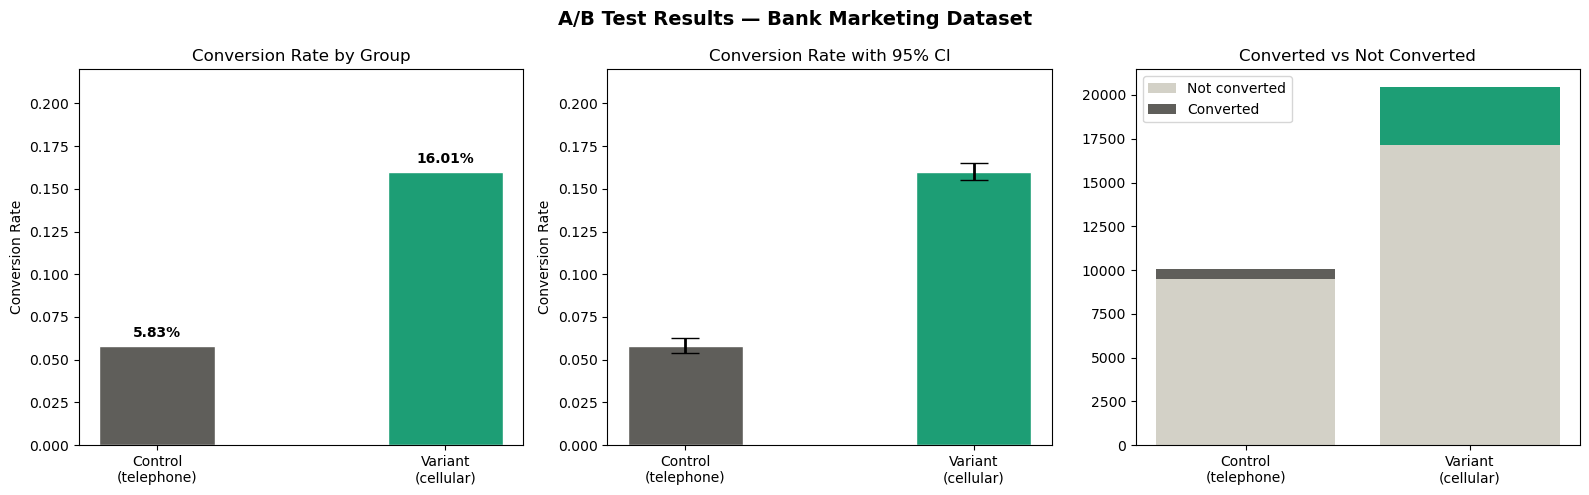

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('A/B Test Results — Bank Marketing Dataset', fontsize=14, fontweight='bold')

groups      = ['Control\n(telephone)', 'Variant\n(cellular)']
rates       = [0.0583, 0.1601]
ci_lower    = [0.0537, 0.1552]
ci_upper    = [0.0629, 0.1650]
colors      = ['#5F5E5A', '#1D9E75']


bars = axes[0].bar(groups, rates, color=colors, width=0.4, edgecolor='white')
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_ylim(0, 0.22)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{rate:.2%}', ha='center', fontweight='bold')


errors_low  = [r - l for r, l in zip(rates, ci_lower)]
errors_high = [u - r for r, u in zip(rates, ci_upper)]
axes[1].bar(groups, rates, color=colors, width=0.4,
            yerr=[errors_low, errors_high], capsize=10,
            error_kw={'linewidth': 2}, edgecolor='white')
axes[1].set_title('Conversion Rate with 95% CI')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_ylim(0, 0.22)


not_converted = [10045 - 586, 20443 - 3273]
converted     = [586, 3273]
x = np.arange(len(groups))
axes[2].bar(x, not_converted, label='Not converted', color='#D3D1C7')
axes[2].bar(x, converted, bottom=not_converted,
            label='Converted', color=colors)
axes[2].set_title('Converted vs Not Converted')
axes[2].set_xticks(x)
axes[2].set_xticklabels(groups)
axes[2].legend()

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("=" * 50)
print("       FINAL A/B TEST DECISION")
print("=" * 50)
print(f"  Control rate  :   5.83%")
print(f"  Variant rate  :  16.01%")
print(f"  Lift          :  +10.18 pp  (2.74x)")
print(f"  Z-statistic   : -28.39")
print(f"  P-value       :  ~0.000000")
print(f"  Chi2          :  806.89")
print(f"  95% CI diff   :  [+9.37%  —  +11.00%]")
print("-" * 50)
print("  DECISION: ✅ IMPLEMENT CELLULAR CONTACT")
print("  Cellular converts at 2.74x the rate of")
print("  telephone. Result is highly significant.")
print("=" * 50)

       FINAL A/B TEST DECISION
  Control rate  :   5.83%
  Variant rate  :  16.01%
  Lift          :  +10.18 pp  (2.74x)
  Z-statistic   : -28.39
  P-value       :  ~0.000000
  Chi2          :  806.89
  95% CI diff   :  [+9.37%  —  +11.00%]
--------------------------------------------------
  DECISION: ✅ IMPLEMENT CELLULAR CONTACT
  Cellular converts at 2.74x the rate of
  telephone. Result is highly significant.
